In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.optimize import minimize
from scipy.sparse.linalg import expm_multiply, eigsh, expm
import warnings
warnings.filterwarnings('ignore')

# Quantum chemistry
from pyscf import gto, scf, ao2mo
from openfermion import FermionOperator, normal_ordered, jordan_wigner, get_sparse_operator, count_qubits
from openfermion.circuits import (
    uccsd_singlet_paramsize,
    uccsd_singlet_generator
)
from openfermion.transforms import jordan_wigner


## __BUILD HAMILTONIAN__ ##

In [7]:
def build_one_electron(integral, n_orb):
    H = FermionOperator()
    for p in range(n_orb):
        for q in range(n_orb):
            if abs(integral[p, q]) < 1e-12:
                continue
            for sigma in range(2):
                i = 2 * p + sigma 
                j = 2 * q + sigma
                H += FermionOperator(((i, 1), (j, 0)), integral[p, q])
    return H

In [8]:
def build_two_electron(eri_mo, n_orb):
    H = FermionOperator()
    for p in range(n_orb):
        for q in range(n_orb):
            for r in range(n_orb):
                for s in range(n_orb):
                    g = eri_mo[p,q,r,s]
                    if abs(g) < 1e-12:
                        continue
                    for sigma in range(2):
                        for tau in range(2):
                            i = 2 * p + sigma
                            j = 2 * r + tau
                            k = 2 * s + tau
                            l = 2 * q + sigma
                            H += FermionOperator(
                                ((i, 1), (j, 1), (k, 0), (l, 0)),
                                0.5 * g
                            )
    return H

    H_mat  : matriks Hamiltonian elektronik (2^n_q × 2^n_q)
    T_mat  : matriks kinetik
    V_mat  : matriks potensial (Ven + Vee)
    E_nuc  : energi repulsi inti
    n_q    : jumlah qubit
    n_orb  : jumlah orbital spasial

In [9]:
def build_hamiltonian(bond_length, angle_deg=104.5):
    #bangun molekul
    mol = gto.Mole()

    angle = np.radians(angle_deg / 2)
    hx = bond_length * np.sin(angle)
    hz = bond_length * np.cos(angle)
    mol.atom = (f"O 0 0 0; "
                f"H  {hx:.6f} 0  {hz:.6f}; "
                f"H -{hx:.6f} 0  {hz:.6f}")
    mol.basis = 'sto-3g'
    mol.verbose = 0
    mol.build()

    #hartree-fock
    mf = scf.RHF(mol)
    mf.run()
    C = mf.mo_coeff
    n_orb = C.shape[1]
    E_nuc = mol.energy_nuc()
    n_elec = mol.nelectron

    #integral dalam basis MO
    T_ao = mol.intor('int1e_kin')
    V_ao = mol.intor('int1e_nuc')
    T_mo  = C.T @ T_ao @ C
    V_mo  = C.T @ V_ao @ C
    eri_mo = ao2mo.kernel(mol, C, compact=False).reshape(n_orb, n_orb, n_orb, n_orb)

    #operator fermion
    H_Kin = normal_ordered(build_one_electron(T_mo, n_orb))
    H_VeN = normal_ordered(build_one_electron(V_mo, n_orb))
    H_Vee = normal_ordered(build_two_electron(eri_mo, n_orb))
    
    # Jordan-Wigner → operator qubit
    T_q   = jordan_wigner(H_Kin)
    VeN_q = jordan_wigner(H_VeN)
    Vee_q = jordan_wigner(H_Vee)
    V_q   = VeN_q + Vee_q
    n_q   = count_qubits(T_q + V_q)

    # Dense matrix
    T_sp = get_sparse_operator(T_q, n_qubits=n_q).tocsr()
    V_sp = get_sparse_operator(V_q, n_qubits=n_q).tocsr()
    H_sp = (T_sp + V_sp).tocsr()

    return H_sp, T_sp, V_sp, E_nuc, n_q, n_orb, n_elec

In [10]:
# ── Uji cepat pada panjang ikatan ekuilibrium ───────────────────────
print("Membangun Hamiltonian untuk R = 0.74 Å ...")
H_test, T_test, V_test, E_nuc_test, n_q_test, n_orb_test, n_elec_test = build_hamiltonian(0.74)

evals_test, _ = eigsh(H_test, k=1, which='SA')
E_exact_test  = evals_test[0] + E_nuc_test

print(f"  Orbital spasial   : {n_orb_test}")
print(f"  Jumlah qubit      : {n_q_test}")
print(f"  Dimensi Hilbert   : {2**n_q_test} × {2**n_q_test}")
print(f"  E_nuc             : {E_nuc_test:.6f} Ha")
print(f"  E_exact (FCI)     : {E_exact_test:.6f} Ha")

Membangun Hamiltonian untuk R = 0.74 Å ...
  Orbital spasial   : 7
  Jumlah qubit      : 14
  Dimensi Hilbert   : 16384 × 16384
  E_nuc             : 11.893874 Ha
  E_exact (FCI)     : -74.761543 Ha


## __QUANTUM CIRCUIT: ANSATZ__ ##

In [11]:
def _apply_gate_1q(psi, gate, qubit, n_qubits):
    """Terapkan gate 2×2 pada satu qubit via moveaxis — O(2^n), tanpa matriks besar."""
    psi = psi.reshape([2] * n_qubits)
    psi = np.moveaxis(psi, qubit, 0)          # bawa qubit target ke axis-0
    psi = gate @ psi.reshape(2, -1)           # kalikan gate 2×2
    psi = psi.reshape([2] * n_qubits)
    psi = np.moveaxis(psi, 0, qubit)          # kembalikan ke posisi semula
    return psi.reshape(-1)

#gate primitives
def ry_gate(psi, theta, qubit, n_qubits):
    c, s = np.cos(theta / 2), np.sin(theta / 2)
    gate = np.array([[c, -s], [s, c]], dtype=complex)
    return _apply_gate_1q(psi, gate, qubit, n_qubits)

def cnot_full(psi, control, target, n_qubits):
    psi   = psi.reshape([2] * n_qubits)
    psi   = np.moveaxis(psi, [control, target], [0, 1])  # ctrl→ax0, tgt→ax1
    shape = psi.shape
    psi   = psi.reshape(2, 2, -1).copy()
    psi[1] = psi[1, ::-1, :]                             # flip target saat ctrl=1
    psi   = psi.reshape(shape)
    psi   = np.moveaxis(psi, [0, 1], [control, target])  # kembalikan
    return psi.reshape(-1)

In [12]:
#inisialisasi state dengan hartee fock
def prepare_hf_state(n_qubits, n_electrons):
    psi = np.zeros(2 ** n_qubits, dtype=complex)
    hf_idx = sum(1 << (n_qubits - 1 - i) for i in range(n_electrons))
    psi[hf_idx] = 1.0
    return psi

    params      : array parameter θ (panjang = n_qubits × (depth+1))
    n_qubits    : jumlah qubit
    n_electrons : jumlah elektron (untuk inisialisasi HF state)
    depth       : jumlah lapisan Ry-CNOT
    cnot_layer  : matrix CNOT entangling (precomputed)

In [14]:
#from openfermion.circuit import uccsd_singlet_paramsize, uccsd_singlet_generator
from openfermion.transforms import jordan_wigner
from scipy.linalg import expm

def build_uccsd_ansatz(params, n_qubits, n_electrons, H_sparse=None):
    """UCCSD ansatz: U = exp(T - T†) applied to |HF⟩"""
    # Generator UCCSD dalam basis spin-orbital
    ucc_op  = uccsd_singlet_generator(params, n_qubits, n_electrons)
    jw_op   = jordan_wigner(ucc_op)
    A       = get_sparse_operator(jw_op, n_qubits=n_qubits).toarray()
    U       = expm(A - A.conj().T)          # unitary evolution
    psi_hf  = prepare_hf_state(n_qubits, n_electrons)
    return U @ psi_hf

# Cek dulu berapa parameter yang dibutuhkan
n_orb   = 7           # H₂O STO-3G
n_elec  = 10
n_p     = uccsd_singlet_paramsize(n_orb * 2, n_elec)
print(f"UCCSD n_params = {n_p}")   # → jauh lebih sedikit dari 98

UCCSD n_params = 65


In [16]:
#hardware efficient ansantz
def prepare_ansatz(params, n_qubits, n_electrons, n_orbitals):
    n_alpha = n_electrons // 2
    n_beta = n_electrons // 2

    #generator uccsd
    ucc_generator = uccsd_singlet_generator(
        params, n_qubits, n_alpha + n_beta
    )

    #Jordan-wigner transform
    jw_generator = jordan_wigner(ucc_generator)
    
    # Matriks eksponensial: U = exp(A - A†)
    gen_mat = get_sparse_operator(jw_generator, n_qubits=n_qubits).toarray()
    U = expm(gen_mat - gen_mat.conj().T)

    # Aplikasikan ke HF state
    psi_hf = prepare_hf_state(n_qubits, n_electrons)
    return U @ psi_hf

# Jumlah parameter UCCSD untuk H₂O (10e, 7 orbital, 14 qubit)
n_params_uccsd = uccsd_singlet_paramsize(n_qubits=14, n_electrons=10)
print(f"Jumlah parameter UCCSD: {n_params_uccsd}")  # → ~35 params (lebih sedikit dari HEA!)

# Inisialisasi θ₀ = 0 → tepat di titik HF (bukan random!)
theta0 = np.zeros(n_params_uccsd)

Jumlah parameter UCCSD: 65


In [17]:
# ── Konfigurasi Global ───────────────────────────────────────────────
N_QUBITS    = 14          # 2 orbital spasial × 2 spin = 4 qubit
N_ELECTRONS = 10          # H₂ memiliki 2 elektron
DEPTH       = 6          # kedalaman ansatz
N_PARAMS    = N_QUBITS * (DEPTH + 1)   # = 12 parameter

# Verifikasi HF state
psi_hf_demo = prepare_hf_state(N_QUBITS, N_ELECTRONS)
hf_index    = np.argmax(np.abs(psi_hf_demo))

print(f"Konfigurasi ansatz:")
print(f"  n_qubits    = {N_QUBITS}")
print(f"  n_electrons = {N_ELECTRONS}")
print(f"  depth       = {DEPTH}")
print(f"  n_params    = {N_PARAMS}  (Ry rotations)")
print(f"  HF state    = |1100⟩  (index {hf_index} dari {2**N_QUBITS} basis states)")


Konfigurasi ansatz:
  n_qubits    = 14
  n_electrons = 10
  depth       = 6
  n_params    = 98  (Ry rotations)
  HF state    = |1100⟩  (index 16368 dari 16384 basis states)


## __BUILD VQE__ ##

In [18]:
#nilai ekspektasi
def expect_value(psi, H_sp):
    return float(np.real(psi.conj() @ H_sp @ psi))

    params      : parameter ansatz θ saat ini (array float)
    H_mat       : matriks Hamiltonian elektronik
    n_qubits    : jumlah qubit
    n_electrons : jumlah elektron
    depth       : kedalaman ansatz
    cnot_layer  : precomputed CNOT matrix
    history     : list yang akan diisi dengan nilai E tiap iterasi

In [19]:
#optimizer klasik untuk menghitung E(0) dan menyimpan riwayat energi tiap iterasi
def optimizer_cl(params, H_sp, n_qubits, n_electrons, depth, history):
    psi = prepare_ansatz(params, n_qubits, n_electrons, depth)
    E = expect_value(psi, H_sp)
    history.append(E)
    return E

Jalankan VQE: minimasi E(θ) = ⟨ψ(θ)|H|ψ(θ)⟩ dengan optimizer klasik.

In [20]:
def run_vqe(H_sp, n_qubits, n_electrons, depth=2, method='COBYLA', 
            n_restarts=5, seed=42, verbose=False):

    rng      = np.random.RandomState(seed)
    n_params = n_qubits * (depth + 1)
    best     = {'E_vqe': np.inf, 'energy_history': [], 'n_iters': 0}

    opts_map = {
        'COBYLA'     : {'maxiter': max(10000, 150 * n_params), 'rhobeg': 0.3},
        'Nelder-Mead': {'maxiter': 5000, 'xatol': 1e-8, 'fatol': 1e-8},
        'BFGS'       : {'maxiter': 1000, 'gtol': 1e-8},
        'L-BFGS-B'   : {'maxiter': 1000, 'ftol': 1e-12},
    }
    opts = opts_map.get(method, {'maxiter': 2000})

    for trial in range(n_restarts):
        history = []
        # Paruh pertama: θ₀ kecil (dekat identitas → dekat HF state)
        # Paruh kedua : θ₀ lebar (eksplorasi ruang parameter)
        theta0 = (rng.uniform(-0.3, 0.3, n_params) if trial < n_restarts // 2
                  else rng.uniform(-np.pi, np.pi, n_params))
        
        if verbose:
            print(f"  [Restart {trial+1}/{n_restarts}] "
                  f"n_params={n_params}, method={method}")
            
        iter_count = [0]
        def callback(theta):
            iter_count[0] += 1
            if verbose and iter_count[0] % 50 == 0 and history:
                print(f"    iter {iter_count[0]:4d} | E = {history[-1]:.8f} Ha")

        try:
            res = minimize(
                optimizer_cl,
                theta0,
                args=(H_sp, n_qubits, n_electrons, depth, history),
                method=method,
                callback=callback,
                options=opts
        )
        except Exception as exc:
            print(f"  [!] Restart {trial+1} error: {exc}")
            continue

        if verbose:
            print(f"  → selesai: E={res.fun:.8f} Ha | "
                  f"{len(history)} evals | success={res.success}")

        if res.fun < best['E_vqe']:
            best = {
                'E_vqe'          : res.fun,
                'optimal_params' : res.x.copy(),
                'energy_history' : history.copy(),
                'n_iters'        : len(history),
                'trial'          : trial + 1,
                'success'        : res.success
            }
    return best

## __MENCOBA VQE PADA BOND LENGTH EKUILIBRIUM (R = 0.74 Å)__ ##

In [21]:
R_DEMO = 0.74  # Å — panjang ikatan ekuilibrium H₂O

print(f"  VQE Demo: H₂O, R = {R_DEMO} Å, Basis STO-3G")

  VQE Demo: H₂O, R = 0.74 Å, Basis STO-3G


In [ ]:
#hamiltonian
H_demo, T_demo, V_demo, E_nuc_demo, n_q_demo, _, n_elec_demo = \
    build_hamiltonian(R_DEMO) 
print(f"\n[1] Hamiltonian: n_qubits={n_q_demo}, dim={2**n_q_demo}×{2**n_q_demo}")

#energi eksak (FCI diagonalisasi)
evals_d, evecs_d = eigsh(H_demo, k=1, which='SA')
E_exact_d = evals_d[0] + E_nuc_demo
print(f"[2] E_exact (FCI)  = {E_exact_d:.8f} Ha")

#energi hartee fock pada ansatz theta=0
psi_hf_d = prepare_hf_state(n_q_demo, n_elec_demo)
E_hf_d = expect_value(psi_hf_d, H_demo) + E_nuc_demo
print(f"[3] E_HF (θ=0)     = {E_hf_d:.8f} Ha  |  error = {abs(E_hf_d - E_exact_d):.2e} Ha")

#jalanin VQE
vqe_d = run_vqe(
    H_demo, n_q_demo, n_elec_demo,
    depth      = DEPTH,
    method     = 'COBYLA',
    n_restarts = 2,
    seed       = 42,
    verbose    = True
)

E_vqe_d  = vqe_d['E_vqe'] + E_nuc_demo
err_vqe_d = abs(E_vqe_d - E_exact_d)
corr_pct  = (E_hf_d - E_vqe_d) / (E_hf_d - E_exact_d) * 100

print(f"\n[4] Hasil Akhir VQE:")
print(f"    E_VQE   = {E_vqe_d:.8f} Ha")
print(f"    E_exact = {E_exact_d:.8f} Ha")
print(f"    |ΔE|    = {err_vqe_d:.2e} Ha")


[1] Hamiltonian: n_qubits=14, dim=16384×16384
[2] E_exact (FCI)  = -74.76154348 Ha
[3] E_HF (θ=0)     = -74.73367698 Ha  |  error = 2.79e-02 Ha
  [Restart 1/2] n_params=98, method=COBYLA


In [59]:
# Fidelity
psi_opt_d    = prepare_ansatz(vqe_d['optimal_params'], n_q_demo,
                               n_elec_demo, DEPTH)
psi_exact_d  = evecs_d[:, 0]
fidelity_d   = abs(psi_opt_d.conj() @ psi_exact_d) ** 2
print(f"    Fidelity |⟨ψ_VQE|ψ_FCI⟩|² = {fidelity_d:.6f}")

    Fidelity |⟨ψ_VQE|ψ_FCI⟩|² = 0.860297


## __KURVA ENERGI POTENSIAL__ ##

In [60]:
#trotterisasi
def suzuki_trotter(T_sp, V_sp, psi0, dt, n_steps):
    """
    Second-order Suzuki-Trotter time evolution U(t) = e^{-iHt}.
    
    Evolusi waktu orde-2 Suzuki-Trotter: U(dt)^n_steps |ψ₀⟩
    Menggunakan expm_multiply → tidak membangun matriks 2^n × 2^n.
    """
    psi = psi0.astype(complex).copy()
    for _ in range(n_steps):
        psi  = expm_multiply(-1j * (dt / 2) * V_sp, psi)
        psi  = expm_multiply(-1j * dt * T_sp, psi)
        psi  = expm_multiply(-1j * (dt / 2) * V_sp, psi)
    psi /= np.linalg.norm(psi) 
    return psi

In [61]:
bond_lengths = np.array([
    0.5, 0.6, 0.7, 0.74, 0.8, 0.9, 1.0,
    1.2, 1.4, 1.6, 1.8, 2.0, 2.4, 2.8, 3.0
])

DT      = 0.05
N_STEPS = 20

In [62]:
#looping
results = []
CHEM_ACC = 1.6e-3   # Hartree
print(f"{'─'*77}")
print(f"  {'R(Å)':>5} │ {'E_exact(Ha)':>13} │ {'E_VQE(Ha)':>13} │ "
      f"{'E_Trotter(Ha)':>13} │ {'|ΔE_VQE|(Ha)':>12}")
print(f"{'─'*77}")

for R in bond_lengths:
    #hamiltonian 
    H_sp, T_sp, V_sp, E_nuc, n_q, _, n_elec = build_hamiltonian(R)

    #eksak
    evals, evecs = eigsh(H_sp, k=1, which='SA')
    E_exact      = evals[0] + E_nuc
    psi0         = evecs[:, 0].astype(complex)

    #VQE
    vqe_res = run_vqe(H_sp, n_q, n_elec,
                      depth=DEPTH, method='COBYLA',
                      n_restarts=1, seed=42, verbose=False)
    E_vqe   = vqe_res['E_vqe'] + E_nuc
    delta_v = abs(E_vqe - E_exact)

    #suzuki-trotter
    psi_trot = suzuki_trotter(T_sp, V_sp, psi0, DT, N_STEPS)
    E_trot   = expect_value(psi_trot, H_sp) + E_nuc
    delta_t  = abs(E_trot - E_exact)

    results.append({
        'bond_length'   : R,
        'E_exact'       : E_exact,
        'E_vqe'         : E_vqe,
        'E_trotter'     : E_trot,
        'delta_vqe'     : delta_v,
        'delta_trotter' : delta_t,
        'n_iters_vqe'   : vqe_res['n_iters'],
        'history_vqe'   : vqe_res['energy_history'],
        'E_nuc'         : E_nuc,
    })

    print(f"  {R:5.2f}   │  {E_exact:11.6f}  │  {E_vqe:11.6f}  │  "
          f"{E_trot:11.6f}  │  {delta_v:.2e}")

─────────────────────────────────────────────────────────────────────────────
   R(Å) │   E_exact(Ha) │     E_VQE(Ha) │ E_Trotter(Ha) │ |ΔE_VQE|(Ha)
─────────────────────────────────────────────────────────────────────────────
   0.50   │   -73.137649  │   -72.209243  │   -73.092221  │  9.28e-01
   0.60   │   -74.146204  │   -73.389422  │   -74.096151  │  7.57e-01
   0.70   │   -74.643694  │   -74.136088  │   -74.598848  │  5.08e-01
   0.74   │   -74.761543  │   -74.340355  │   -74.719876  │  4.21e-01
   0.80   │   -74.883002  │   -73.702109  │   -74.846426  │  1.18e+00
   0.90   │   -74.987693  │   -74.061046  │   -74.959354  │  9.27e-01
   1.00   │   -75.019855  │   -74.076997  │   -74.998611  │  9.43e-01
   1.20   │   -74.985126  │   -74.053096  │   -74.973914  │  9.32e-01
   1.40   │   -74.910272  │   -74.183424  │   -74.904610  │  7.27e-01
   1.60   │   -74.840495  │   -74.382627  │   -74.837689  │  4.58e-01
   1.80   │   -74.790571  │   -74.137912  │   -74.789210  │  6.53e-01
   

In [63]:
df = pd.DataFrame([{
    'R (Å)'          : f"{r['bond_length']:.2f}",
    'E_exact (Ha)'   : f"{r['E_exact']:.6f}",
    'E_VQE (Ha)'     : f"{r['E_vqe']:.6f}",
    'E_Trotter (Ha)' : f"{r['E_trotter']:.6f}",
    '|ΔE_VQE| (Ha)'  : f"{r['delta_vqe']:.2e}",
    '|ΔE_Trot| (Ha)' : f"{r['delta_trotter']:.2e}",
    'Iter VQE'       : r['n_iters_vqe'],
    'Chem.Acc.'      : '✓' if r['delta_vqe'] < 1.6e-3 else '✗',
} for r in results])

print("Tabel Perbandingan Lengkap:")
print(df.to_string(index=False))

Tabel Perbandingan Lengkap:
R (Å) E_exact (Ha) E_VQE (Ha) E_Trotter (Ha) |ΔE_VQE| (Ha) |ΔE_Trot| (Ha)  Iter VQE Chem.Acc.
 0.50   -73.137649 -72.209243     -73.092221      9.28e-01       4.54e-02     14700         ✗
 0.60   -74.146204 -73.389422     -74.096151      7.57e-01       5.01e-02     14700         ✗
 0.70   -74.643694 -74.136088     -74.598848      5.08e-01       4.48e-02     14700         ✗
 0.74   -74.761543 -74.340355     -74.719876      4.21e-01       4.17e-02     14700         ✗
 0.80   -74.883002 -73.702109     -74.846426      1.18e+00       3.66e-02     14700         ✗
 0.90   -74.987693 -74.061046     -74.959354      9.27e-01       2.83e-02     14700         ✗
 1.00   -75.019855 -74.076997     -74.998611      9.43e-01       2.12e-02     14700         ✗
 1.20   -74.985126 -74.053096     -74.973914      9.32e-01       1.12e-02     14700         ✗
 1.40   -74.910272 -74.183424     -74.904610      7.27e-01       5.66e-03     14700         ✗
 1.60   -74.840495 -74.382627   

In [64]:
# Statistik ringkas
dv = np.array([r['delta_vqe']     for r in results])
dt = np.array([r['delta_trotter'] for r in results])
print(f"\n{'─'*55}")
print(f"Statistik Error Energi:")
print(f"{'':20s} {'VQE':>12}   {'Suzuki-Trotter':>14}")
print(f"{'─'*55}")
print(f"{'Rata-rata |ΔE|':20s} {np.mean(dv):12.2e}   {np.mean(dt):14.2e} Ha")
print(f"{'Maksimum |ΔE|':20s} {np.max(dv):12.2e}   {np.max(dt):14.2e} Ha")
print(f"{'Minimum |ΔE|':20s} {np.min(dv):12.2e}   {np.min(dt):14.2e} Ha")
print(f"{'─'*55}")


───────────────────────────────────────────────────────
Statistik Error Energi:
                              VQE   Suzuki-Trotter
───────────────────────────────────────────────────────
Rata-rata |ΔE|           6.90e-01         1.93e-02 Ha
Maksimum |ΔE|            1.18e+00         5.01e-02 Ha
Minimum |ΔE|             3.53e-01         9.11e-06 Ha
───────────────────────────────────────────────────────


## __PLOT KURVA ENERGI POTENSIAL__ ##

In [66]:
# Cek dengan print dulu:
idx_min = np.argmin(E_ex)
print(f"DEBUG: idx_min={idx_min}, R={R_arr[idx_min]}, E={E_ex[idx_min]}")

DEBUG: idx_min=6, R=1.0, E=-75.01985477819795


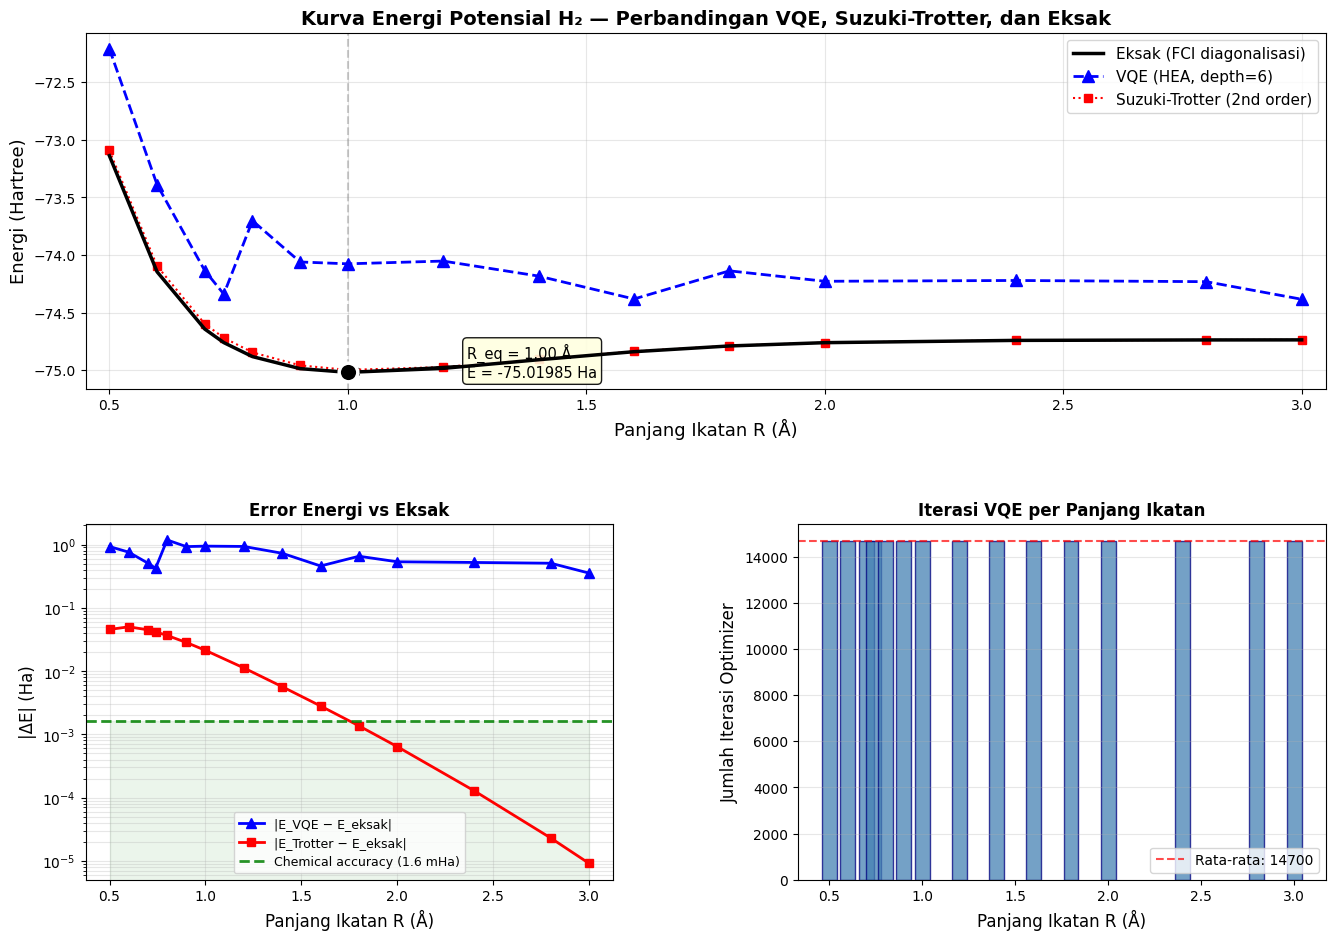

In [ ]:
R_arr  = np.array([r['bond_length']   for r in results])
E_ex   = np.array([r['E_exact']        for r in results])
E_vq   = np.array([r['E_vqe']          for r in results])
E_tr   = np.array([r['E_trotter']      for r in results])
dv_arr = np.array([r['delta_vqe']      for r in results])
dt_arr = np.array([r['delta_trotter']  for r in results])

fig = plt.figure(figsize=(16, 11))
gs  = gridspec.GridSpec(2, 2, hspace=0.38, wspace=0.35)

# ── 1: Kurva energi potensial ────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, :])
ax1.plot(R_arr, E_ex, 'k-',   lw=2.5, zorder=5, label='Eksak (FCI diagonalisasi)')
ax1.plot(R_arr, E_vq, 'b^--', lw=2.0, ms=8,  zorder=4, label=f'VQE (HEA, depth={DEPTH})')
ax1.plot(R_arr, E_tr, 'rs:',  lw=1.5, ms=6,  zorder=3, label='Suzuki-Trotter (2nd order)')

# Tandai minimum eksak
idx_min = np.argmin(E_ex)
R_eq    = R_arr[idx_min]      # = 1.0
E_eq    = E_ex[idx_min]       # = -75.01985
ax1.axvline(R_arr[idx_min], color='gray', ls='--', alpha=0.4, lw=1.5)
ax1.scatter([R_arr[idx_min]], [E_ex[idx_min]], s=180, color='black',
            zorder=10, edgecolor='white', lw=2.5)
ax1.annotate(f'R_eq = {R_eq:.2f} Å\nE = {E_eq:.5f} Ha',   # ← pakai variabel
            xy     = (R_eq, E_eq),
            xytext = (R_eq + 0.25, E_eq - 0.04),
            fontsize=10.5, color='black',
            bbox=dict(boxstyle='round,pad=0.3', fc='lightyellow', alpha=0.9),
            arrowprops=dict(arrowstyle='->', color='black', lw=1.5))

ax1.set_xlabel('Panjang Ikatan R (Å)', fontsize=13)
ax1.set_ylabel('Energi (Hartree)', fontsize=13)
ax1.set_title('Kurva Energi Potensial H₂O — Perbandingan VQE, Suzuki-Trotter, dan Eksak',
              fontsize=14, weight='bold')
ax1.legend(fontsize=11, loc='upper right')
ax1.grid(True, alpha=0.3)
ax1.set_xlim(R_arr[0]-0.05, R_arr[-1]+0.05)

# ── 2: Log error vs eksak ────────────────────────────────────────────
ax2 = fig.add_subplot(gs[1, 0])
ax2.semilogy(R_arr, dv_arr, 'b^-', lw=2, ms=7, label='|E_VQE − E_eksak|')
ax2.semilogy(R_arr, dt_arr, 'rs-', lw=2, ms=6, label='|E_Trotter − E_eksak|')
ax2.axhline(1.6e-3, color='green', ls='--', lw=2, alpha=0.85,
            label='Chemical accuracy (1.6 mHa)')
ax2.fill_between(R_arr, 0, 1.6e-3, alpha=0.08, color='green')
ax2.set_xlabel('Panjang Ikatan R (Å)', fontsize=12)
ax2.set_ylabel('|ΔE| (Ha)', fontsize=12)
ax2.set_title('Error Energi vs Eksak', fontsize=12, weight='bold')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3, which='both')

# ── 3: Jumlah iterasi VQE ────────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 1])
bars = ax3.bar(R_arr, [r['n_iters_vqe'] for r in results],
               width=0.08, color='steelblue', alpha=0.75, edgecolor='navy')
ax3.set_xlabel('Panjang Ikatan R (Å)', fontsize=12)
ax3.set_ylabel('Jumlah Iterasi Optimizer', fontsize=12)
ax3.set_title('Iterasi VQE per Panjang Ikatan', fontsize=12, weight='bold')
ax3.grid(True, alpha=0.3, axis='y')

# Anotasi rata-rata
avg_iters = np.mean([r['n_iters_vqe'] for r in results])
ax3.axhline(avg_iters, color='red', ls='--', lw=1.5, alpha=0.7,
            label=f'Rata-rata: {avg_iters:.0f}')
ax3.legend(fontsize=10)

plt.show()

In [ ]:
# Analisis Parameter Optimal & Verifikasi Final State (R = 0.74 Å)
# ══════════════════════════════════════════════════════════════════════

# Ambil hasil VQE pada R = 0.74 Å dari sweep
#r_eq = next(r for r in results if r['bond_length'] == 0.74)

# Re-build Hamiltonian untuk mendapatkan H_mat
H_eq, T_eq, V_eq, E_nuc_eq, n_q_eq, _, n_elec_eq = build_hamiltonian(0.74)
vqe_eq    = run_vqe(H_eq, n_q_eq, n_elec_eq,
                    depth=DEPTH, method='COBYLA',
                    n_restarts=5, seed=42, verbose=False)
theta_star = vqe_eq['optimal_params']

print("\nParameter Optimal θ* pada R = 0.74 Å")
print(f"{'─'*55}")
for d in range(DEPTH + 1):
    print(f"  Layer {d}: ", end="")
    for q in range(n_q_eq):
        idx = d * n_q_eq + q
        print(f"θ[{idx}]={theta_star[idx]:+.4f}", end="  ")
    print()
print(f"{'─'*55}")

#eigsh untuk ground state
evals_eq, evecs_eq = eigsh(H_eq, k=1, which='SA')
E_exact_eq         = evals_eq[0] + E_nuc_eq
psi_exact_eq       = evecs_eq[:, 0]

# Verifikasi state optimal
psi_star = prepare_ansatz(theta_star, n_q_eq, n_elec_eq, DEPTH)
E_final  = expect_value(psi_star, H_eq) + E_nuc_eq
fidelity = abs(psi_star.conj() @ psi_exact_eq) ** 2

print(f"\nVerifikasi State Optimal:")
print(f"  E_VQE     = {E_final:.8f} Ha")
print(f"  E_exact   = {E_exact_eq:.8f} Ha")
print(f"  |ΔE|      = {abs(E_final - E_exact_eq):.2e} Ha  "
      f"{'✓ Chemical accuracy' if abs(E_final - E_exact_eq) < CHEM_ACC else '✗'}")
print(f"  Fidelity  = {fidelity:.6f}  (|⟨ψ_VQE|ψ_FCI⟩|²)")
 
# Distribusi probabilitas — [FIX-6] format label sesuai n_q_eq qubit
probs_vqe   = np.abs(psi_star) ** 2
probs_exact = np.abs(psi_exact_eq) ** 2
 
threshold = 0.01
sig_idx   = [i for i in range(len(probs_vqe))
             if probs_vqe[i] > threshold or probs_exact[i] > threshold]

top_n   = 20
sig_idx = sorted(sig_idx, key=lambda i: probs_exact[i] + probs_vqe[i], reverse=True)[:top_n]
sig_idx = sorted(sig_idx)
 
# [FIX-6] Label format sesuai jumlah qubit aktual
fmt = f'0{n_q_eq}b'
basis_labels = [f'|{i:{fmt}}⟩' for i in range(2 ** n_q_eq)]
 
fig2, ax = plt.subplots(figsize=(14, 4))
x, w = np.arange(len(sig_idx)), 0.35
ax.bar(x - w/2, probs_exact[sig_idx], w, label='Eksak (FCI)',  color='crimson',   alpha=0.8)
ax.bar(x + w/2, probs_vqe[sig_idx],   w, label='VQE optimal', color='steelblue', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels([basis_labels[i] for i in sig_idx], fontsize=8, rotation=45, ha='right')
ax.set_xlabel('Basis State Komputasi', fontsize=12)
ax.set_ylabel('Probabilitas |⟨basis|ψ⟩|²', fontsize=12)
ax.set_title(
    f'Distribusi Probabilitas State — R = 0.74 Å  '
    f'(Fidelity = {fidelity:.4f}, top {len(sig_idx)} states)',
    fontsize=12, weight='bold'
)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('vqe_state_distribution.png', dpi=150, bbox_inches='tight')
plt.show()